<font color=#009afa size=50>DAT-6002 - Fundamentals of Artificial Intelligence</font><br>
<font size=50>WRIT1 Part 2 - Neural Networks</font><br>
<font size=20 color=#00c382>From Scratch MLP - Bank Data</font><br>

|**Assessment Code:** |WRIT1|
|---|---|
|**Author:**|Tom Rowan|
|**Course:**|DAT6002_S2_25|
|**Course Tutor:**|Imtiaz Hussain Khan, PhD|


**Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.**

https://archive.ics.uci.edu/dataset/222/bank+marketing

---

# Initialise Notebook

In [117]:
# Install Requirements Using Pip
%pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [118]:
# Standard Libraries
import sys
import time
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
#from matplotlib import colormaps
#import matplotlib.colors as mcolors
#from matplotlib.pyplot import figure
#import matplotlib.ticker as mticker
#import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests


# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [119]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [120]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow', newline=True):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
        
    # Newline - defaul to a newline
    nl=None if newline else ' '
    
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}', end=nl)

### Check for Internet Access

In [121]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [122]:
internet_required = False

In [123]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


---
# Load the Dataset

In [124]:
if online:
    # Fetch the dataset from the Internet
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')
else:
    # Load the dataset from local file
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')

In [125]:
# Full 45 feature model dataset
#
#  df = pd.read_csv('bank_full_scaled_20260322.csv', delimiter=',')

In [126]:
df.shape

(45211, 29)

In [127]:
df.sample(5)

,age,balance,housing,loan,campaign,previous,y,pdays_binned,month_numeric,education_numeric,...,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown
21160,1.041921,-0.413262,0.0,0.0,-0.246560,-0.25194,0.0,0.0,0.636364,1.000000,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
18271,0.665225,2.950909,1.0,0.0,1.044601,-0.25194,0.0,0.0,0.545455,1.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
11250,-0.370689,0.251493,0.0,0.0,-0.569351,-0.25194,0.0,0.0,0.454545,0.333333,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
11728,1.324443,-0.447419,0.0,0.0,-0.246560,-0.25194,0.0,0.0,0.454545,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
13532,0.288529,-0.400781,1.0,0.0,-0.569351,-0.25194,0.0,0.0,0.545455,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


### Pre-MLP Processing

Now it is necessary to split the input dataset into two parts - testing and training data.<br>
I am using an 80/20 split with 80% of the data going towards training.<br>
Validation data will be furthewr split from this chunk within the MLP class below.

Initially, I was using the following simple code to split the data:

```
# Split data frame into 80/20
df_train = df.sample(frac = 0.8, random_state = 67)
# Creating dataframe with rest of the 20% values
df_test = df.drop(df_train.index)
```

However, this does not guarantee that the data includes exactly the same proportions of yes/no results as shown here:<br>

```
# Print the percentage distribution of the target variable 'y'
print ((df_train['y'].value_counts(normalize=True).round(4) * 100))
# Print the percentage distribution of the target variable 'y'
print ((df_test['y'].value_counts(normalize=True).round(4) * 100))
```

Results:

```
y
0.0    88.42
1.0    11.58
Name: proportion, dtype: float64
y
0.0    87.83
1.0    12.17
Name: proportion, dtype: float64
```

Therefore, I wrote the following function to split the data so that each chunk contains the same proportions.

```
def split_test_train (frac=0.8, random_state=67):

    # Separate yes and no into two dataframes
    df_yes = df[df['y'] == 1]
    df_no = df[df['y'] == 0]

    # Sample 80% from each to maintain the 11.7% ratio
    df_train_yes = df_yes.sample(frac=frac, random_state=random_state)
    df_train_no = df_no.sample(frac=frac, random_state=random_state)

    # Combine and Shuffle to prevent date order being learned by the MLP
    df_train = pd.concat([df_train_yes, df_train_no]).sample(frac=1, random_state=random_state)
    df_test = df.drop(df_train.index).sample(frac=1, random_state=random_state)

    return df_train, df_test

# Used like this:
df_train, df_test = split_test_train()
```

This is all implemented inside the MLP class so that the code can be used to split off test and train, as well as being used to split validation from the training data.

In [128]:
df.columns

Index(['age', 'balance', 'housing', 'loan', 'campaign', 'previous', 'y',
       'pdays_binned', 'month_numeric', 'education_numeric',
       'poutcome_numeric', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown'],
      dtype='str')

### Function to draw a generic neural network diagram

This function was 100% created by Google Gemini for speed as it is only used to illustrate the network in the report.

In [129]:

def draw_neural_network(ax, left, right, bottom, top, layer_sizes):

    v_spacing = (top - bottom)/float(max(layer_sizes))
    h_spacing = (right - left)/float(len(layer_sizes) - 1)
    
    # Draw nodes
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing*(layer_size - 1)/2. + (top + bottom)/2.
        for m in range(layer_size):
            circle = plt.Circle((n*h_spacing + left, layer_top - m*v_spacing), 
                                v_spacing/4., color='skyblue', ec='k', zorder=4)
            ax.add_artist(circle)
            
            # Add labels for layers
            if m == 0:
                if n == 0: ax.text(n*h_spacing + left, top + 0.1, f'Input Layer (N = {layer_size})', ha='center')
                if n == 1: ax.text(n*h_spacing + left, top + 0.1, f'Hidden Layer ({layer_size})', ha='center')
                if n == 2: ax.text(n*h_spacing + left, top + 0.1, f'Output Layer (M = {layer_size})', ha='center')

    # Draw edges (weights)
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing*(layer_size_a - 1)/2. + (top + bottom)/2.
        layer_top_b = v_spacing*(layer_size_b - 1)/2. + (top + bottom)/2.
        for m in range(layer_size_a):
            for o in range(layer_size_b):
                line = plt.Line2D([n*h_spacing + left, (n + 1)*h_spacing + left],
                                  [layer_top_a - m*v_spacing, layer_top_b - o*v_spacing], 
                                  c='gray', lw=0.5, alpha=0.3)
                ax.add_artist(line)



# Neural Network

"Construct a three-layer feedforward neural network consisting of N input neurons, 10 hidden neurons, and M output neuron(s)."

In a neural network, the forward pass consists of two main operations per layer:

    Linear Transformation: Z=X⋅W+b

    Activation Function: A=σ(Z)

For a binary classification task like this, the Sigmoid function is the standard choice for the output layer because it squashes any input into a value between 0 and 1, which we can interpret as a probability.  (citation)

Loss is calculated using the Binary Cross-Entropy function:

$$L = -\frac{1}{N} \sum_{i=1}^{n} [y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i)]$$

## MLP Class 

In [130]:
class MLP_From_Scratch:

    # Constructor
    def __init__(self, dataset, **kwargs):

        # Handle Arguments

        self.dataset = dataset

        _random_seed = kwargs.get('random_seed', 67)
        self.debug = kwargs.get('debug', False)

        _test_train_split = kwargs.get('test_train_split', 0.8)    # Default to 80% of the supplied data
        _validation_split = kwargs.get('validation_split', 0.2)    # Default to 20% of the training data

        # Split off training, test and validationdatasets

        df_train, df_test = self._split_stratified (data_set=self.dataset, fraction=_test_train_split, random_state=_random_seed)
        df_train, df_val = self._split_stratified (data_set=df_train, fraction=1-_validation_split, random_state=_random_seed)

        # Split inot X and y for each dataset
        X_train, y_train = self._x_and_y_split(df_train)
        X_test, y_test = self._x_and_y_split(df_test)
        val_X, val_y = self._x_and_y_split(df_val)

        # Convert provided data to numpy arrays
        self.X_np_train = X_train.to_numpy()
        self.y_np_train = y_train.to_numpy().reshape(-1,1)

        self.X_np_val = val_X.to_numpy()
        self.y_np_val = val_y.to_numpy().reshape(-1,1)

        self.X_np_test = X_test.to_numpy()
        self.y_np_test = y_test.to_numpy().reshape(-1,1)

        # Additional Model Parameters
        _act_func = kwargs.get('act_func', 'relu')                      # Hidden layer only, defaults to relu
        _no_hidden_neurons = kwargs.get('no_hidden_neurons', 10)        # Defaults to 10 hidden neurons, per assessment specification
        _no_output_neurons = kwargs.get('no_output_neurons', 1)
        self.output_threshold = kwargs.get('output_threshold', 0.5)
        self.loss_type = kwargs.get('loss_type', 'bce')                 # Loss type for backpropagation, default to Binary Cross-Entropy (BCE)

        # Define Model Parameters
        self.no_input_neurons  = self.X_np_train.shape[1]               # Set dynamically based on the input dataset
        self.no_hidden_neurons = _no_hidden_neurons          
        self.no_output_neurons = _no_output_neurons
        self.learning_rate = 0.03          
        self.act_func = _act_func

        # Initialize Weights with small random numbers
        # 
        #   input_neurons --> weights_0 --> hidden_neurons --> weights_1 --> output_neurons
        #                                   biases_1                         biases_2
        #
        np.random.seed(_random_seed)

        self.weights_0 = np.random.randn(self.no_input_neurons, self.no_hidden_neurons) 
        self.weights_1 = np.random.randn(self.no_hidden_neurons, self.no_output_neurons)

        self.biases_1 = np.zeros((1, self.no_hidden_neurons))
        self.biases_2 = np.zeros((1, self.no_output_neurons))


        if self.debug:
            print_output("No Input Layer Neurons", self.no_input_neurons)
            print_output("No Input to Hidden Weights", self.weights_0.size, colour='blue')

            print_output("No Hidden Layer Neurons", self.no_hidden_neurons)
            print_output("No Hidden Layer Biases", self.biases_1.size, colour='blue')
            print_output("Hidden Layer Activation", self.act_func, colour='green')

            print_output("No Hidden to Output Weights", self.weights_1.size, colour='blue')
        
            print_output("No Output Layer Neurons", self.no_output_neurons)
            print_output("No Output Layer Biases", self.biases_2.size, colour='blue')

            print ("")

            print_output("Training 'Yes' Ratio", f"{np.mean(self.y_np_train):.4f}", colour='green')
            print_output("Validation 'Yes' Ratio", f"{np.mean(self.y_np_val):.4f}", colour='green')
            print_output("Test 'Yes' Ratio", f"{np.mean(self.y_np_test):.4f}", colour='green')

            print ("")

            # Setup plot
            fig = plt.figure(figsize=(10, 8))
            ax = fig.gca()
            ax.axis('off')

            draw_neural_network(ax, .1, .9, .1, .9, [self.no_input_neurons, self.no_hidden_neurons, self.no_output_neurons])
            plt.savefig(f'graphs/mlp_architecture_{now_datetime_timestamp}.png', bbox_inches='tight', dpi=300)
            plt.show()

    #
    # ***** Data Handling Functions
    # 
    
    def _split_stratified (self, data_set, fraction=0.8, random_state=67):

        # Separate yes and no into two dataframes
        df_yes = data_set[data_set['y'] == 1]
        df_no = data_set[data_set['y'] == 0]

        # Sample 80% from each to maintain the 11.7% ratio
        df_train_yes = df_yes.sample(frac=fraction, random_state=random_state)
        df_train_no = df_no.sample(frac=fraction, random_state=random_state)

        # Combine and Shuffle to prevent date order being learned by the MLP
        df_train = pd.concat([df_train_yes, df_train_no]).sample(frac=1, random_state=random_state)
        df_test = data_set.drop(df_train.index).sample(frac=1, random_state=random_state)

        return df_train, df_test
    
    def _x_and_y_split (self, df):
        # Split datasets into X (features) and y (labels)
        df_X = df.drop(columns='y')
        df_y = df['y']
        return df_X, df_y
    
    def _check_proportion (df, label_col='y'):
        # Print the percentage distribution of the target variable
        distribution = df[label_col].value_counts(normalize=True).round(4) * 100
        print (distribution)
        return distribution

    #
    # ***** Activation Functions 
    #

    def _relu(self, x):
        return np.maximum(0, x)

    def _relu_derivative(self, x):
        return (x > 0).astype(float)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _sigmoid_derivative(self, x):
        return x * (1 - x)

    # Generic version to allow replacement of the activation function if needed
    
    #def _act_func(self, x):
    #    return self._sigmoid(x)

    #def _act_func_deriv(self, x):
    #    return self._sigmoid_derivative(x)
    
    #
    # ***** MLP Process Functions 
    #

    def _feed_forward(self, X):
        sum_synapse_0 = np.dot(X, self.weights_0) + self.biases_1
        hidden_layer = self._relu(sum_synapse_0)
        
        sum_synapse_1 = np.dot(hidden_layer, self.weights_1) + self.biases_2
        output_layer = self._sigmoid(sum_synapse_1)
        
        # Return everything
        return X, hidden_layer, output_layer
    
    
    def _back_propagation(self, output_layer):

        error_output_layer = self.y_np_train - output_layer
        
        # This is used for monitoring the error during training, but is not used in the backpropagation calculations
        average_error = np.mean(np.abs(error_output_layer))
        
        # Choose Loss Type and calculate delta_output accordingly
        if self.loss_type == 'bce':
            delta_output = error_output_layer
        elif self.loss_type == 'mse':
            derivative_output = self._sigmoid_derivative(output_layer)
            delta_output = error_output_layer * derivative_output

        return delta_output, average_error
    
    
    def _back_propagation_hidden(self, delta_output, hidden_layer):
    
        # Transpose the numpy array
        weights_1T = self.weights_1.T
        
        delta_output_weight = delta_output.dot(weights_1T)

        if self.act_func == 'sigmoid':
            delta_hidden_layer = delta_output_weight * self._sigmoid_derivative(hidden_layer)
        else:
            delta_hidden_layer = delta_output_weight * self._relu_derivative(hidden_layer)
        
        hidden_layerT = hidden_layer.T
        input_x_delta1 = hidden_layerT.dot(delta_output)

        return delta_hidden_layer, input_x_delta1
    

    def _weight_bias_update(self, input_layer, input_x_delta1, delta_hidden_layer, delta_output):

        m = input_layer.shape[0]                                                          # Batch size to normalise the gradient
        
        self.weights_1 = self.weights_1 + (input_x_delta1 / m * self.learning_rate)       # Divide by m to compute the average gradient
        
        input_layerT = input_layer.T
        input_x_delta0 = input_layerT.dot(delta_hidden_layer)
        self.weights_0 = self.weights_0 + (input_x_delta0 / m * self.learning_rate)                                                            

        self.biases_1 = self.biases_1 + np.sum(delta_hidden_layer, axis=0, keepdims=True) / m * self.learning_rate
        self.biases_2 = self.biases_2 + np.sum(delta_output, axis=0, keepdims=True) / m * self.learning_rate 

    # Run the feed forward process and return the predicted classes (0 or 1) based on the output threshold
    def _get_predictions(self, X):
        _, _, output = self._feed_forward(X)
        return (output > self.output_threshold).astype(int)


    # Calculate accuracy by comparing predicted classes to true labels
    def _calculate_accuracy(self, X, y):
        y_pred = self._get_predictions(X)
        return np.mean(y_pred == y) * 100
    

    def _get_confusion_matrix(self, X_data=None, y_data=None):
            
        # Default to the test set if no specific data is provided
        if X_data is None:
            X_data = self.X_np_test
            y_data = self.y_np_test

        y_pred = self._get_predictions(X_data)
        
        # Flatten the arrays to ensure they are 1D to compare
        y_true = y_data.flatten()
        y_pred = y_pred.flatten()
        
        # Calculate True Positives, True Negatives, False Positives, and False Negatives
        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        accuracy = (tp + tn) / len(y_true)
        
        return np.array([[tn, fp], [fn, tp]]), accuracy

    #
    # ***** Public Functions 
    #

    # Allows updating of model parameters (e.g. learning rate, output threshold) without needing to retrain the model from scratch
    def set_model_parameters(self, **kwargs):
        self.learning_rate = kwargs.get('learning_rate', self.learning_rate)
        self.output_threshold = kwargs.get('output_threshold', self.output_threshold)

    def train_network(self, epochs, **kwargs):

        # Set up parameters
        self.learning_rate = kwargs.get('learning_rate', self.learning_rate)
        self.loss_type = kwargs.get('loss_type', 'bce')

        self.train_error_history = []
        self.valid_error_history = [] 

        epsilon = 1e-15  # Small value to prevent log(0) in loss calculation

        for epoch in range(epochs):

            # Forward
            input_layer, hidden_layer, output_layer = self._feed_forward(self.X_np_train)

            # --- Calculate Binary Cross-Entropy Loss ---
            output_layer_clipped = np.clip(output_layer, epsilon, 1 - epsilon)
            loss = -np.mean(self.y_np_train * np.log(output_layer_clipped) + (1 - self.y_np_train) * np.log(1 - output_layer_clipped))
        
            # --- Monitor Weights ---
            # This tells you if your weights are becoming massive (Exploding Gradient)
            w_hidden_mean = np.mean(np.abs(self.weights_0))
            w_out_mean = np.mean(np.abs(self.weights_1))
                
            # Back prop (Output)
            delta_output, train_error = self._back_propagation(output_layer)
            
            # Back prop (Hidden)
            delta_hidden_layer, input_x_delta1 = self._back_propagation_hidden(delta_output, hidden_layer)
            
            # Update Weights
            self._weight_bias_update(input_layer, input_x_delta1, delta_hidden_layer, delta_output)

            if epoch % 100 == 0:
                #  Use the feed_forward method but with validation data
                _, _, test_output = self._feed_forward(self.X_np_val)
                
                # Calculate validation error (Mean Absolute Error)
                valid_error = np.mean(np.abs(self.y_np_val - test_output))

                # Calculate BCE for validation set
                test_output_clipped = np.clip(test_output, epsilon, 1 - epsilon)
                val_loss = -np.mean(self.y_np_val * np.log(test_output_clipped) + (1 - self.y_np_val) * np.log(1 - test_output_clipped))
                
                # Store calculated losses for graphing later
                self.train_error_history.append(loss) 
                self.valid_error_history.append(val_loss)

                if self.debug:
                    print_output("Epoch", f"{epoch} - ", newline=False, colour='cyan')
                    print_output("Training Err", f"{train_error:.4f} ", newline=False, colour='yellow')
                    print_output("Validation Err", f"{valid_error:.4f}", newline=False, colour='yellow')
                    print_output("Loss", f"{loss:.4f}", newline=False, colour='yellow')
                    print_output("Hidden Weights Mean", f"{w_hidden_mean:.4f}", newline=False, colour='yellow')
                    print_output("Output Weights Mean", f"{w_out_mean:.4f}", newline=True, colour='yellow')
                else:
                    print(".", end='')

                    
    # Evaluate the model on the provided dataset and return accuracy
    # Allows specifying a custom output threshold for prediction
    # Allows proving a custom dataset instead of the default test set
    def evaluate(self, X_data=None, y_data=None):
            
        # Default to the test set if no specific data is provided
        if X_data is None:
            X_data = self.X_np_test
            y_data = self.y_np_test
        
        self.accuracy = self._calculate_accuracy(X_data, y_data)
        return self.accuracy 
    

    def plot_error(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.train_error_history, label='Training Loss')
        plt.plot(self.valid_error_history, label='Validation Loss', linestyle='--')
        plt.xlabel('Epochs (x100)')
        plt.ylabel('Binary Cross-Entropy Loss')
        plt.title('Training vs Validation Loss')
        plt.legend()
        plt.savefig(f'graphs/mlp_training_validation_loss_{now_datetime_timestamp}.png')
        plt.show()


    def plot_confusion_matrix(self):

        matrix, accuracy = self._get_confusion_matrix()
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(matrix, cmap='Blues')

        # Add colorbar
        plt.colorbar(im)

        # Set labels
        classes = ['No (0)', 'Yes (1)']
        ax.set_xticks(np.arange(len(classes)))
        ax.set_yticks(np.arange(len(classes)))
        ax.set_xticklabels(classes)
        ax.set_yticklabels(classes)

        # Rotate the tick labels and set their alignment.
        plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

        # Loop over data dimensions and create text annotations.
        for i in range(2):
            for j in range(2):
                text = ax.text(j, i, matrix[i, j],
                            ha="center", va="center", color="black", fontsize=14)

        ax.set_title("Confusion Matrix Heatmap")
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        plt.tight_layout()
        plt.savefig(f'graphs/mlp_confusion_matrix_{now_datetime_timestamp}_threshold_{self.output_threshold}.png')
        plt.show()


    # Text Representation
    def print_confusion_matrix(self):
        matrix, self.accuracy = self._get_confusion_matrix() 
        print(f"{'':>15} | {'Predicted No':>12} | {'Predicted Yes':>12} |")
        print("-" * 48)
        print(f"{'Actual No':>15} | {matrix[0][0]:>12} | {matrix[0][1]:>12} |")
        print(f"{'Actual Yes':>15} | {matrix[1][0]:>12} | {matrix[1][1]:>12} |")
        print("-" * 48)
        print (f"Accuracy: {self.accuracy:.2f}%")


    # Export the model weights and biases to a JSON file
    def save_weights(self, filename):
        weights_data = {
            'weights_0': self.weights_0.tolist(),
            'weights_1': self.weights_1.tolist(),
            'biases_1': self.biases_1.tolist(),
            'biases_2': self.biases_2.tolist()
        }
        with open(filename, 'w') as f:
            json.dump(weights_data, f, indent=4)

    # Load the model weights and biases from a JSON file
    def load_weights(self, filename):
        with open(filename, 'r') as f:
            weights_data = json.load(f)
            self.weights_0 = np.array(weights_data['weights_0'])
            self.weights_1 = np.array(weights_data['weights_1'])
            self.biases_1 = np.array(weights_data['biases_1'])
            self.biases_2 = np.array(weights_data['biases_2'])

    def get_report(self, X_data, y_data):
        # Get the confusion matrix components
        matrix, accuracy = self._get_confusion_matrix(X_data, y_data)
        tn, fp = matrix[0]
        fn, tp = matrix[1]

        # Calculate metrics (with safety for division by zero)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        print(f"--- Performance Report (Threshold: {self.output_threshold}) ---")
        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f} (Reliability of 'Yes' predictions)")
        print(f"Recall:    {recall:.4f} (Ability to find 'Yes' customers)")
        print(f"F1-Score:  {f1:.4f} (Overall balance)")
        print("---------------------------------------------------------")
        
        return {"acc": accuracy, "prec": precision, "rec": recall, "f1": f1}
        

This is a binary classification problem, which implies 1 output neuron

No Input Layer Neurons: 28
No Input to Hidden Weights: 280
No Hidden Layer Neurons: 10
No Hidden Layer Biases: 10
Hidden Layer Activation: relu
No Hidden to Output Weights: 10
No Output Layer Neurons: 1
No Output Layer Biases: 1

Training 'Yes' Ratio: 0.1170
Validation 'Yes' Ratio: 0.1169
Test 'Yes' Ratio: 0.1170



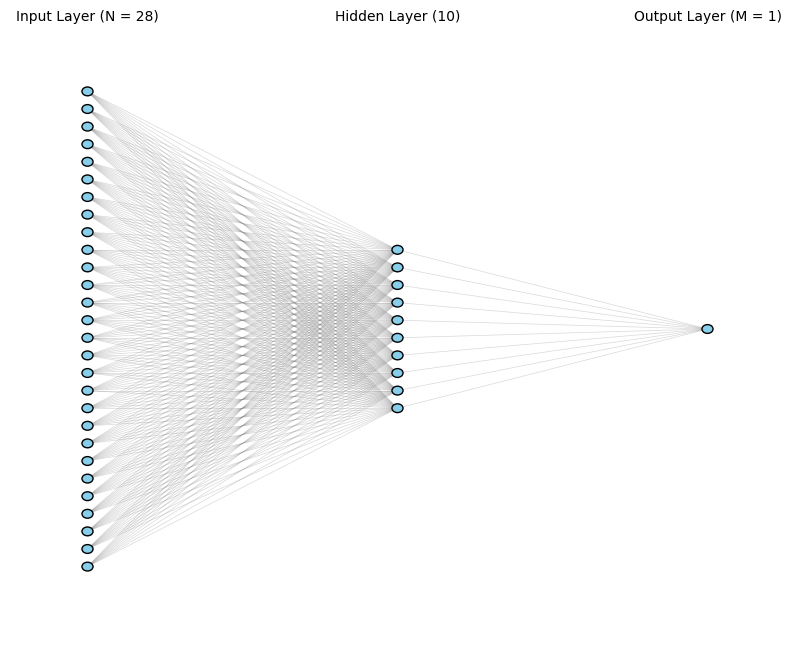

Epoch: 0 -  Training Err: 0.6412  Validation Err: 0.5995 Loss: 1.8728 Hidden Weights Mean: 0.7720 Output Weights Mean: 0.6623
Epoch: 100 -  Training Err: 0.2285  Validation Err: 0.2281 Loss: 0.4622 Hidden Weights Mean: 0.7659 Output Weights Mean: 0.5878
Epoch: 200 -  Training Err: 0.2202  Validation Err: 0.2194 Loss: 0.4123 Hidden Weights Mean: 0.7636 Output Weights Mean: 0.5521
Epoch: 300 -  Training Err: 0.2159  Validation Err: 0.2149 Loss: 0.3938 Hidden Weights Mean: 0.7619 Output Weights Mean: 0.5251
Epoch: 400 -  Training Err: 0.2133  Validation Err: 0.2123 Loss: 0.3829 Hidden Weights Mean: 0.7607 Output Weights Mean: 0.5017
Epoch: 500 -  Training Err: 0.2115  Validation Err: 0.2106 Loss: 0.3753 Hidden Weights Mean: 0.7597 Output Weights Mean: 0.4808
Epoch: 600 -  Training Err: 0.2102  Validation Err: 0.2095 Loss: 0.3694 Hidden Weights Mean: 0.7590 Output Weights Mean: 0.4623
Epoch: 700 -  Training Err: 0.2091  Validation Err: 0.2085 Loss: 0.3647 Hidden Weights Mean: 0.7584 Output

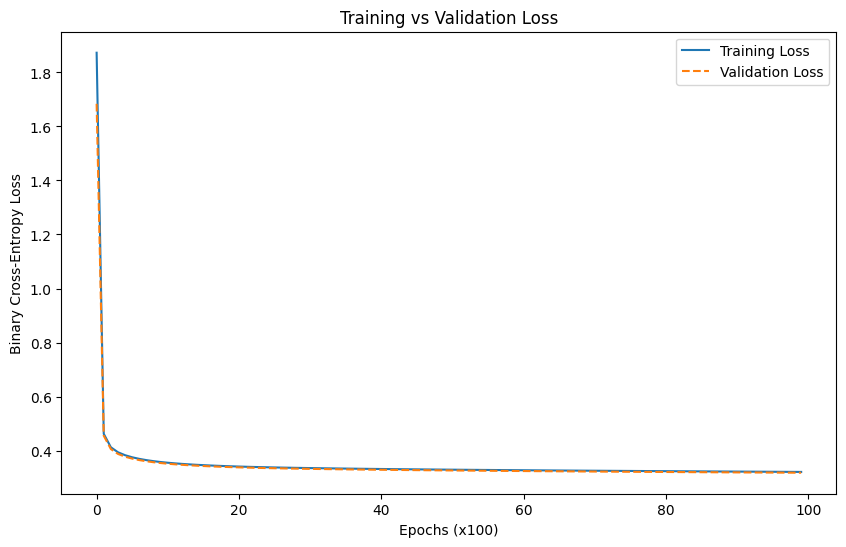

In [131]:
df.reset_index(drop=True, inplace=True)
mlp = MLP_From_Scratch(dataset = df, debug=True, learning_rate=0.03, output_threshold=0.5 )
mlp.train_network(epochs=10000)
mlp.plot_error()


Save out the weights for later use

In [132]:
mlp.save_weights('mlp_weights.json')

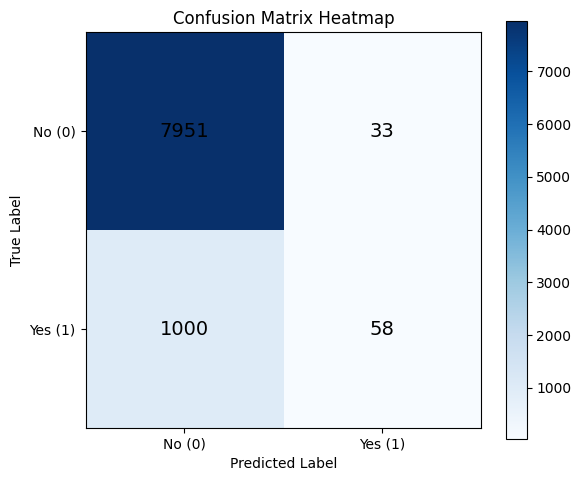

In [133]:
mlp.set_model_parameters(output_threshold=0.50)
mlp.plot_confusion_matrix()

In [134]:
mlp.set_model_parameters(output_threshold=0.50)
mlp.get_report(mlp.X_np_test, mlp.y_np_test)

--- Performance Report (Threshold: 0.5) ---
Accuracy:  0.8858
Precision: 0.6374 (Reliability of 'Yes' predictions)
Recall:    0.0548 (Ability to find 'Yes' customers)
F1-Score:  0.1010 (Overall balance)
---------------------------------------------------------


{'acc': np.float64(0.8857553638575536),
 'prec': np.float64(0.6373626373626373),
 'rec': np.float64(0.054820415879017016),
 'f1': np.float64(0.1009573542210618)}

Exploring different output thresholds as a 'solution' to model bias.

In [135]:
results_list = []

for threshold in np.arange(0, 1, 0.1):
    threshold=threshold.round(1)
    print_output("\nTesting with output bias threshold", threshold, colour='cyan')
    
    # Dynamically update the model's output threshold and re-evaluate without needing to retrain
    mlp.set_model_parameters(output_threshold=threshold)
    report = mlp.get_report(mlp.X_np_test, mlp.y_np_test)
    
    results_list.append({
        'Threshold': threshold,
        'Accuracy': report['acc'],
        'Precision': report['prec'],
        'Recall': report['rec'],
        'F1-Score': report['f1']
    })

    mlp.print_confusion_matrix()

# Convert to DataFrame for plotting
df_metrics = pd.DataFrame(results_list)


Testing with output bias threshold: 0.0
--- Performance Report (Threshold: 0.0) ---
Accuracy:  0.1170
Precision: 0.1170 (Reliability of 'Yes' predictions)
Recall:    1.0000 (Ability to find 'Yes' customers)
F1-Score:  0.2095 (Overall balance)
---------------------------------------------------------
                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |            0 |         7984 |
     Actual Yes |            0 |         1058 |
------------------------------------------------
Accuracy: 0.12%

Testing with output bias threshold: 0.1
--- Performance Report (Threshold: 0.1) ---
Accuracy:  0.6042
Precision: 0.1884 (Reliability of 'Yes' predictions)
Recall:    0.7202 (Ability to find 'Yes' customers)
F1-Score:  0.2986 (Overall balance)
---------------------------------------------------------
                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |         4701 |       

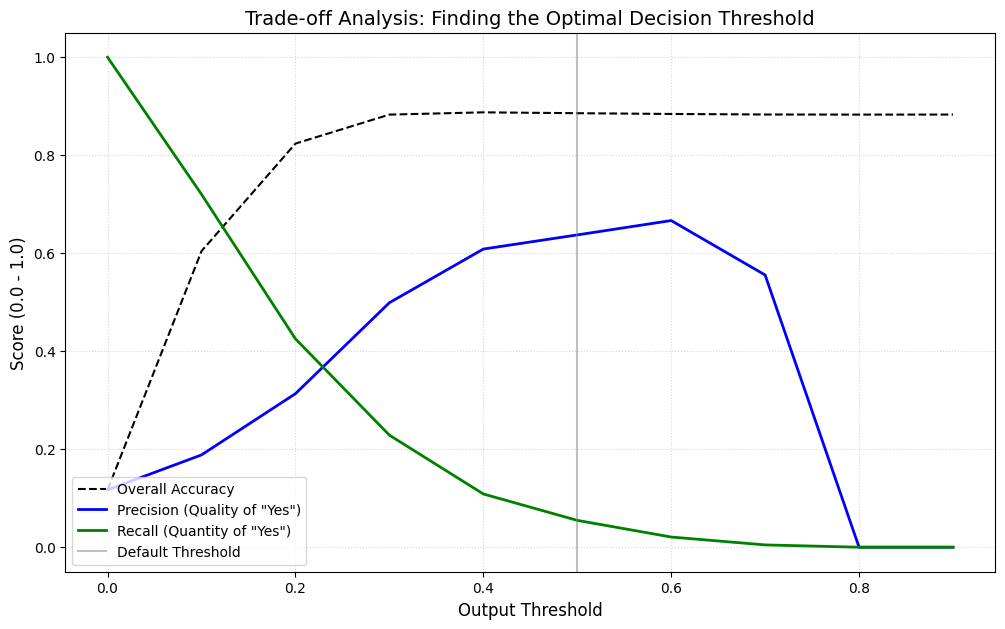

In [136]:
plt.figure(figsize=(12, 7))

# Plot the three main metrics
plt.plot(df_metrics['Threshold'], df_metrics['Accuracy'], label='Overall Accuracy', color='black', linestyle='--')
plt.plot(df_metrics['Threshold'], df_metrics['Precision'], label='Precision (Quality of "Yes")', color='blue', linewidth=2)
plt.plot(df_metrics['Threshold'], df_metrics['Recall'], label='Recall (Quantity of "Yes")', color='green', linewidth=2)

# Mark the standard 0.5 threshold
plt.axvline(x=0.5, color='gray', alpha=0.5, label='Default Threshold')

plt.title('Trade-off Analysis: Finding the Optimal Decision Threshold', fontsize=14)
plt.xlabel('Output Threshold', fontsize=12)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.savefig(f'graphs/mlp_threshold_tradeoff_analysis_{now_datetime_timestamp}.png')
plt.show()

The crossing point of Precision and Recall appears to be at output threshold = 0.23:

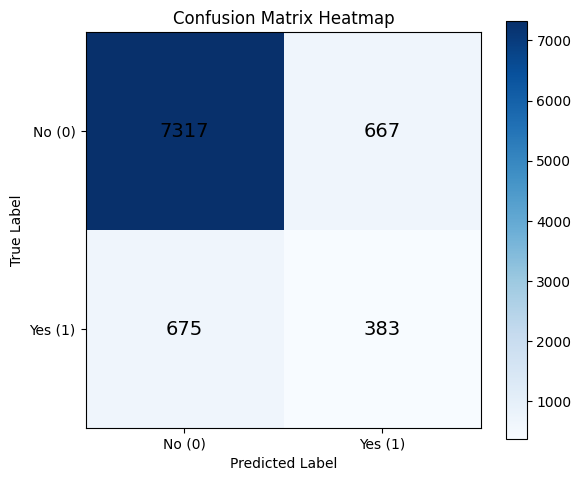

In [137]:
mlp.set_model_parameters(output_threshold=0.23)
mlp.plot_confusion_matrix()

In [138]:
mlp.get_report(mlp.X_np_test, mlp.y_np_test)

--- Performance Report (Threshold: 0.23) ---
Accuracy:  0.8516
Precision: 0.3648 (Reliability of 'Yes' predictions)
Recall:    0.3620 (Ability to find 'Yes' customers)
F1-Score:  0.3634 (Overall balance)
---------------------------------------------------------


{'acc': np.float64(0.851581508515815),
 'prec': np.float64(0.3647619047619048),
 'rec': np.float64(0.3620037807183365),
 'f1': np.float64(0.3633776091081594)}

### Model Evaluation Metrics

| Metric | Mathematical Formula | Description | What it tells the Bank |
| :--- | :---: | :--- | :--- |
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | The proportion of total predictions that were correct. | Overall success rate  |
| **Precision** | $\frac{TP}{TP + FP}$ | The proportion of positive identifications that were actually correct. | "When we call someone a potential customer, how often are we right?" |
| **Recall** | $\frac{TP}{TP + FN}$ | The proportion of actual positives that were identified correctly. | Out of everyone who would have said 'Yes', how many did we actually find? |
| **F1-Score** | $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$ | The mean of Precision and Recall. | The "balanced" score that punishes models for ignoring the minority class. |

In [139]:
sys.exit('Stopping notebook run here.')   

SystemExit: Stopping notebook run here.